
# Solver benchmarks: Van der Pol oscillator

This notebook benchmarks standard ODE solvers on the **Van der Pol oscillator**
\[
\dot x = y,\qquad \dot y = \mu(1-x^2)y - x.
\]

## What this notebook does
- defines the Van der Pol system,
- computes a high-accuracy reference solution,
- benchmarks several solvers,
- compares accuracy, NFE, runtime, and step sizes,
- saves tables and figures to `results/solver_benchmarks/`.



In [15]:

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp



## Experiment parameters

Change `MU` to explore different regimes. A good progression is:
- `MU = 1.0` for a mild nonlinear baseline,
- `MU = 5.0` for a more pronounced nonlinear regime,
- `MU = 20.0` or `MU = 50.0` to see stiffness effects more clearly.


In [16]:

# ----------------------------
# User-adjustable parameters
# ----------------------------
MU = 3.0
T_SPAN = (0.0, 20.0)
Y0 = np.array([2.0, 0.0])   # initial condition [x(0), y(0)]
N_REF = 4000                # number of points on the common reference grid

SOLVERS = ["RK23", "RK45", "DOP853", "Radau", "BDF", "LSODA"]

# Benchmark tolerances for the candidate solvers
RTOL = 1e-6
ATOL = 1e-8

# Tight tolerances for the reference solution
REF_METHOD = "DOP853"
REF_RTOL = 1e-12
REF_ATOL = 1e-14

# Output directory
RESULTS_DIR = Path("results/solver_benchmarks") / f"van_der_pol_mu{str(MU).replace('.', 'p')}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)



## Define the Van der Pol system

In [17]:

def van_der_pol(t, z, mu=MU):
    x, y = z
    dx = y
    dy = mu * (1.0 - x**2) * y - x
    return np.array([dx, dy])

def solve_system(method, rtol, atol, dense_output=True):
    start = time.perf_counter()
    sol = solve_ivp(
        fun=lambda t, z: van_der_pol(t, z, mu=MU),
        t_span=T_SPAN,
        y0=Y0,
        method=method,
        rtol=rtol,
        atol=atol,
        dense_output=dense_output,
    )
    elapsed = time.perf_counter() - start
    return sol, elapsed


## Compute a high-accuracy reference solution

In [18]:

ref_sol, ref_time = solve_system(REF_METHOD, REF_RTOL, REF_ATOL, dense_output=True)

if not ref_sol.success:
    raise RuntimeError(f"Reference solve failed: {ref_sol.message}")

t_ref = np.linspace(T_SPAN[0], T_SPAN[1], N_REF)
y_ref = ref_sol.sol(t_ref)

print(f"Reference method: {REF_METHOD}")
print(f"Reference runtime: {ref_time:.4f} s")
print(f"Reference NFE: {ref_sol.nfev}")
print(f"Reference accepted steps: {len(ref_sol.t) - 1}")


Reference method: DOP853
Reference runtime: 0.0699 s
Reference NFE: 8540
Reference accepted steps: 522


## Plot the reference solution

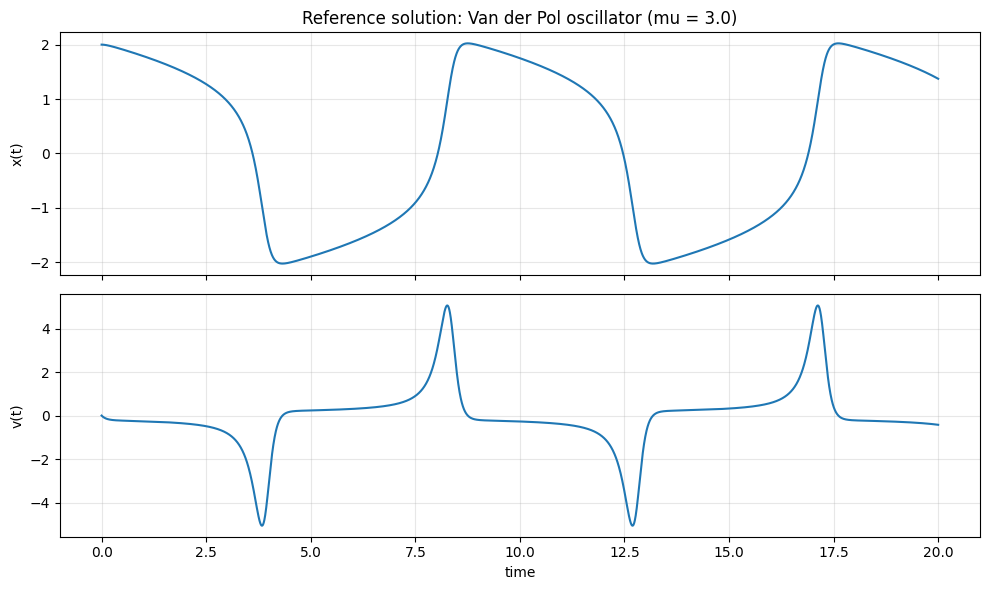

In [19]:

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t_ref, y_ref[0])
axes[0].set_title(f"Reference solution: Van der Pol oscillator (mu = {MU})")
axes[0].set_ylabel("x(t)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_ref, y_ref[1])
axes[1].set_xlabel("time")
axes[1].set_ylabel("v(t)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


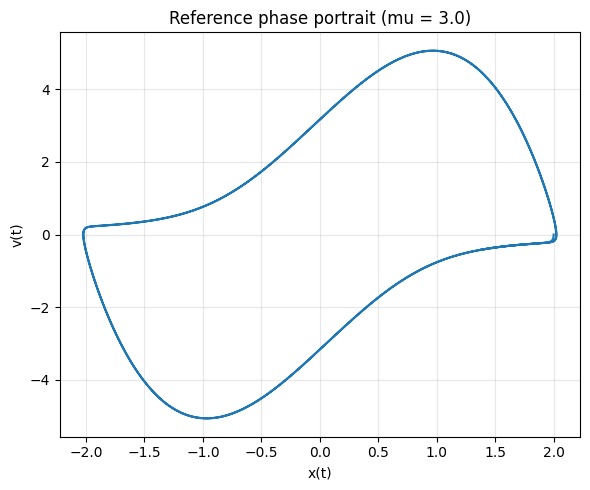

In [20]:

plt.figure(figsize=(6, 5))
plt.plot(y_ref[0], y_ref[1])
plt.title(f"Reference phase portrait (mu = {MU})")
plt.xlabel("x(t)")
plt.ylabel("v(t)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## Benchmark the candidate solvers

Compare each solver to the reference trajectory on the common grid `t_ref`.

### Metrics
- **runtime_sec**: wall-clock runtime,
- **nfev**: number of function evaluations,
- **accepted_steps**: number of accepted mesh intervals,
- **max_abs_err**: max absolute trajectory error over the reference grid,
- **rmse**: root mean squared trajectory error,
- **rel_l2_err**: relative \(L^2\)-type error over the sampled grid.


In [21]:

def compute_errors(y_num, y_ref):
    diff = y_num - y_ref
    max_abs_err = np.max(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    rel_l2_err = np.linalg.norm(diff) / np.linalg.norm(y_ref)
    return max_abs_err, rmse, rel_l2_err

results = []
solutions = {}

for method in SOLVERS:
    sol, elapsed = solve_system(method, RTOL, ATOL, dense_output=True)
    if not sol.success:
        print(f"{method} failed: {sol.message}")
        continue

    y_num = sol.sol(t_ref)
    max_abs_err, rmse, rel_l2_err = compute_errors(y_num, y_ref)

    step_sizes = np.diff(sol.t)
    solutions[method] = {
        "sol": sol,
        "elapsed": elapsed,
        "y_num": y_num,
        "step_sizes": step_sizes,
    }

    results.append(
        {
            "solver": method,
            "runtime_sec": elapsed,
            "nfev": sol.nfev,
            "njev": getattr(sol, "njev", np.nan),
            "nlu": getattr(sol, "nlu", np.nan),
            "accepted_steps": len(sol.t) - 1,
            "min_step": np.min(step_sizes) if len(step_sizes) > 0 else np.nan,
            "max_step": np.max(step_sizes) if len(step_sizes) > 0 else np.nan,
            "mean_step": np.mean(step_sizes) if len(step_sizes) > 0 else np.nan,
            "max_abs_err": max_abs_err,
            "rmse": rmse,
            "rel_l2_err": rel_l2_err,
            "status": sol.status,
            "message": sol.message,
        }
    )

results_df = pd.DataFrame(results).sort_values(["rel_l2_err", "runtime_sec"]).reset_index(drop=True)
results_df


,solver,runtime_sec,nfev,njev,nlu,accepted_steps,min_step,max_step,mean_step,max_abs_err,rmse,rel_l2_err,status,message
0,Radau,0.037135,4732,63,340,620,0.001674,0.165610,0.032258,0.000001,9.951602e-08,6.668852e-08,0,The solver successfully reached the end of the...
1,RK23,0.042459,4826,0,0,1591,0.000199,0.050825,0.012571,0.000036,4.592733e-06,3.077721e-06,0,The solver successfully reached the end of the...
2,DOP853,0.005430,1874,0,0,100,0.004975,0.472036,0.200000,0.000057,7.960904e-06,5.334828e-06,0,The solver successfully reached the end of the...
3,RK45,0.008349,1898,0,0,271,0.004975,0.167309,0.073801,0.000083,8.626286e-06,5.780719e-06,0,The solver successfully reached the end of the...
4,LSODA,0.006965,1311,0,0,604,0.000005,0.088279,0.033113,0.000683,9.079455e-05,6.084401e-05,0,The solver successfully reached the end of the...
5,BDF,0.026597,2006,2,129,785,0.000003,0.100863,0.025478,0.000825,9.416321e-05,6.310144e-05,0,The solver successfully reached the end of the...


## Save the benchmark table

In [22]:

results_csv = RESULTS_DIR / "benchmark_results.csv"
results_df.to_csv(results_csv, index=False)

## Trajectory overlays against the reference solution

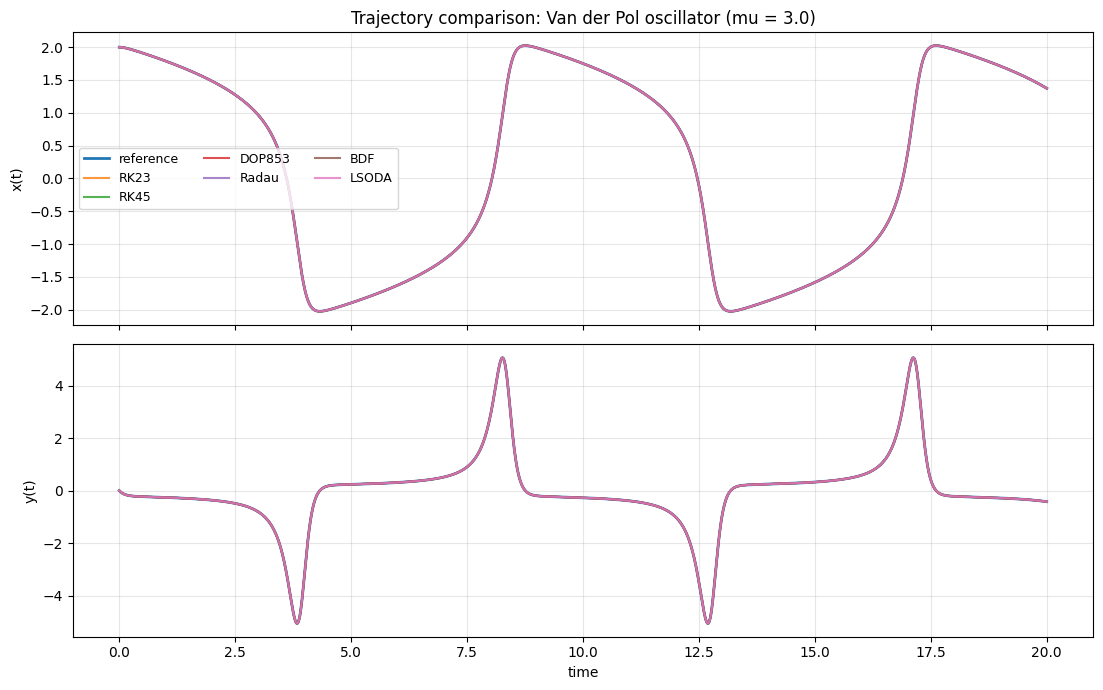

In [23]:

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(t_ref, y_ref[0], linewidth=2, label="reference")
axes[1].plot(t_ref, y_ref[1], linewidth=2, label="reference")

for method, payload in solutions.items():
    y_num = payload["y_num"]
    axes[0].plot(t_ref, y_num[0], alpha=0.8, label=method)
    axes[1].plot(t_ref, y_num[1], alpha=0.8, label=method)

axes[0].set_title(f"Trajectory comparison: Van der Pol oscillator (mu = {MU})")
axes[0].set_ylabel("x(t)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncol=3, fontsize=9)

axes[1].set_xlabel("time")
axes[1].set_ylabel("y(t)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
traj_path = RESULTS_DIR / "trajectory_overlay.png"
plt.savefig(traj_path, dpi=200, bbox_inches="tight")
plt.show()


## Error vs NFE

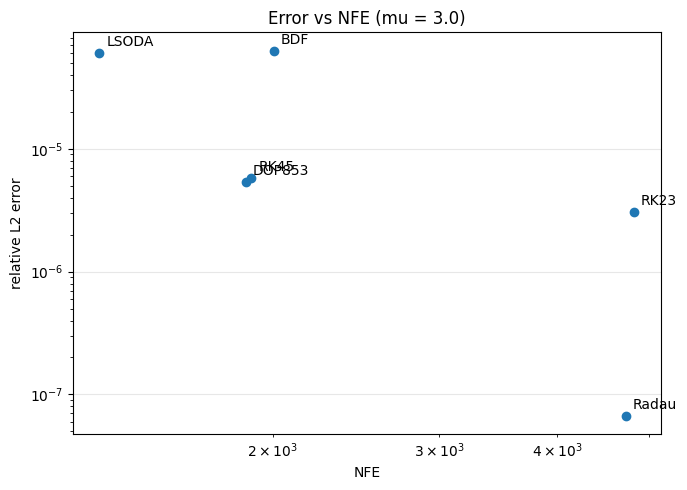

In [24]:

plt.figure(figsize=(7, 5))
plt.scatter(results_df["nfev"], results_df["rel_l2_err"])

for _, row in results_df.iterrows():
    plt.annotate(row["solver"], (row["nfev"], row["rel_l2_err"]), xytext=(5, 5), textcoords="offset points")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("NFE")
plt.ylabel("relative L2 error")
plt.title(f"Error vs NFE (mu = {MU})")
plt.grid(True, alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "error_vs_nfe.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Error vs runtime

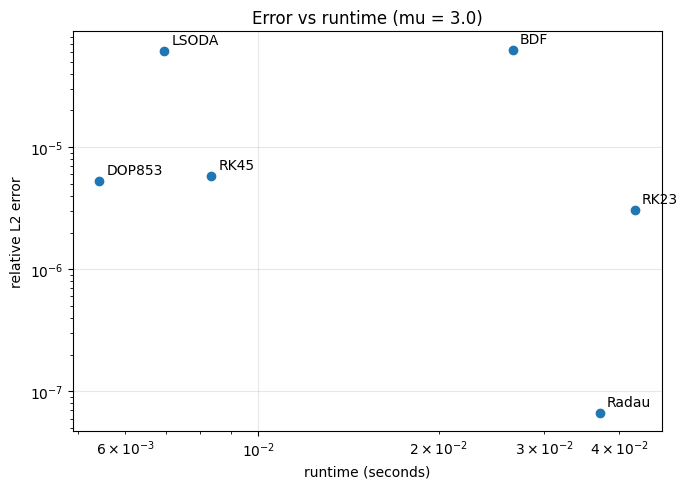

In [25]:

plt.figure(figsize=(7, 5))
plt.scatter(results_df["runtime_sec"], results_df["rel_l2_err"])

for _, row in results_df.iterrows():
    plt.annotate(row["solver"], (row["runtime_sec"], row["rel_l2_err"]), xytext=(5, 5), textcoords="offset points")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("runtime (seconds)")
plt.ylabel("relative L2 error")
plt.title(f"Error vs runtime (mu = {MU})")
plt.grid(True, alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "error_vs_runtime.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Accepted step sizes

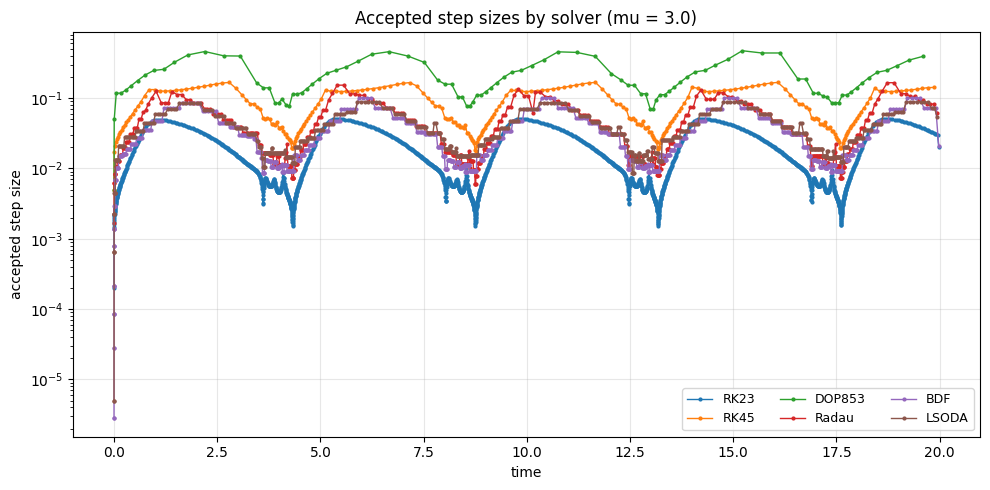

In [26]:

plt.figure(figsize=(10, 5))

for method, payload in solutions.items():
    sol = payload["sol"]
    step_sizes = payload["step_sizes"]
    if len(step_sizes) > 0:
        plt.plot(sol.t[:-1], step_sizes, marker="o", markersize=2, linewidth=1, label=method)

plt.yscale("log")
plt.xlabel("time")
plt.ylabel("accepted step size")
plt.title(f"Accepted step sizes by solver (mu = {MU})")
plt.grid(True, alpha=0.3)
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()

path = RESULTS_DIR / "accepted_step_sizes.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()


## Phase portrait comparison

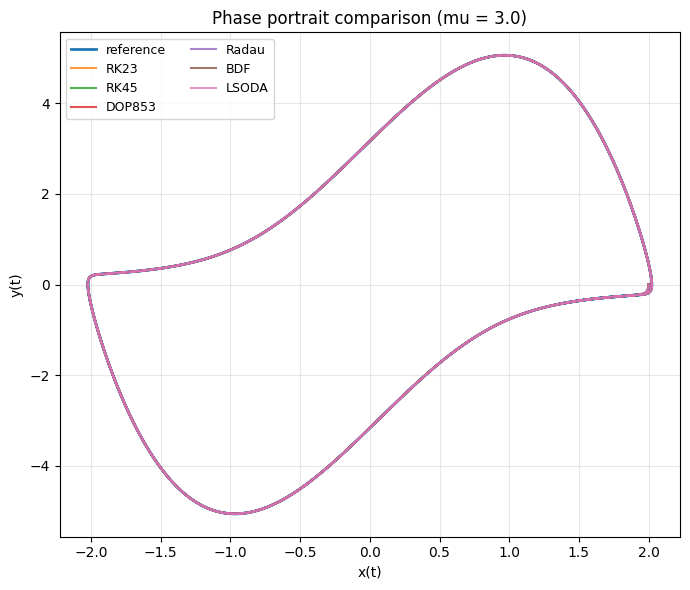

In [27]:

plt.figure(figsize=(7, 6))
plt.plot(y_ref[0], y_ref[1], linewidth=2, label="reference")

for method, payload in solutions.items():
    y_num = payload["y_num"]
    plt.plot(y_num[0], y_num[1], alpha=0.8, label=method)

plt.xlabel("x(t)")
plt.ylabel("y(t)")
plt.title(f"Phase portrait comparison (mu = {MU})")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

path = RESULTS_DIR / "phase_portrait_comparison.png"
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()
